# Sieci neuronowe i Deep Learning
# Temat 2: Adaline i metoda gradientu prostego

## Zadanie 2.1

Rozważyć cztery scenariusze uczenia modelu Adaline na rozważanym zbiorze danych Iris (2 cechy i 2 klasy):
1. Adaline z wykorzystaniem wsadowej wersji metody gradientu prostego, bez standaryzacji cech,
2. Adaline z wykorzystaniem wsadowej wersji metody gradientu prostego, ze standaryzacją cech,
3. Adaline z wykorzystaniem wersji SGD metody gradientu prostego (aproksymacja funkcji celu na podstawie jednego przykładu), bez standaryzacji cech,
4. Adaline z wykorzystaniem wersji SGD metody gradientu prostego (aproksymacja funkcji celu na podstawie jednego przykładu), ze standaryzacją cech.

Dla każdego scenariusza znaleźć optymalny parametr uczenia, a następnie porównać te scenariusze pod kątem szybkości uczenia się sieci neuronowej.

In [ ]:
import os
import pandas as pd

try:
    s = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
    print('From URL:', s)
    df = pd.read_csv(s,
                     header=None,  # Plik nie zawiera wiersza nagłówkowego z nazwami kolumn
                     encoding='utf-8')  # Określa kodowanie znaków pliku

except HTTPError:
    s = 'iris.data'
    print('From local Iris path:', s)
    # Wczytanie danych z lokalnej ścieżki:
    df = pd.read_csv(s,
                     header=None,
                     encoding='utf-8')

From URL: https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data


In [ ]:
import numpy as np

# Wydzielamy dwa gatunki (setosa oraz versicolor):
y = df.iloc[0:100, 4].values  # Wybiera wiersze od 0 do 99 i 5-tą kolumnę
                              # Metoda .values konwertuje tę kolumnę na tablicę NumPy
y = np.where(y == 'Iris-setosa', 0, 1)

# Wydzielamy dwie cechy (sepal length oraz petal length):
X = df.iloc[0:100, [0, 2]].values

In [ ]:
# Poniższy kod przedstawia implementację funkcji,
# która wizualizuje granicę decyzyjną klasyfikatora dla dwuwymiarowej przestrzeni cech.

from matplotlib.colors import ListedColormap


def plot_decision_regions(X, y, classifier, resolution=0.02):  # resolution - rozmiar kroku siatki do wizualizacji przestrzeni

    # Definiujemy listy markerów i kolorów, które będą używane do reprezentowania różnych klas na wykresie:
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    # Tworzymy mapę kolorów ListedColormap na podstawie kolorów określonych w colors.
    # cmap to obiekt, który Matplotlib używa do mapowania liczb na kolory
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Wykres obszarów decyzyjnych:
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1  # Określamy zakresy wartości dla obu cech (-/+ 1)
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))  # Tworzymy dwuwymiarową siatkę punktów do wizualizacji przestrzeni cech
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)  # Liczymy predykcje dla każdego punktu siatki
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)  # Rysowanie konturu granic decyzyjnych
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())  # Ustawiono granice osi wykresu

    # Rysowanie przykładów z rozważanych klas:
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')

In [ ]:
import numpy as np  # Wykorzystana do przekształceń z tablicami oraz do generowania liczb losowych

class AdalineGD:
    """ADAptive LInear NEuron classifier. (GD = Gradient Descent)

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
      Bias unit after fitting.
    losses_ : list
      Mean squared eror loss function values in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)

        self.losses_ = []  # Zamiast self.errors_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            # W przypadku Adaline funkcji activation() nie musimy tak naprawdę definiować,
            # ponieważ jest ona funkcją tożsamościową
            # (można by napisać wprost output = self.net_input(X)).
            # Definiujemy metodę activation jedynie dla uniwersalności kodu
            # (łatwo można np. przerobić go na regresję logistyczną, używając funkcji sigmoidalnej).
            output = self.activation(net_input)
            errors = (y - output)

            # Można tak, ale byłoby mniej efektywnie:
            # for w_j in range(self.w_.shape[0]):
            #    self.w_[w_j] += self.eta * (2.0 * (X[:, w_j]*errors)).mean()

            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)  # Zmiana na >= 0.5

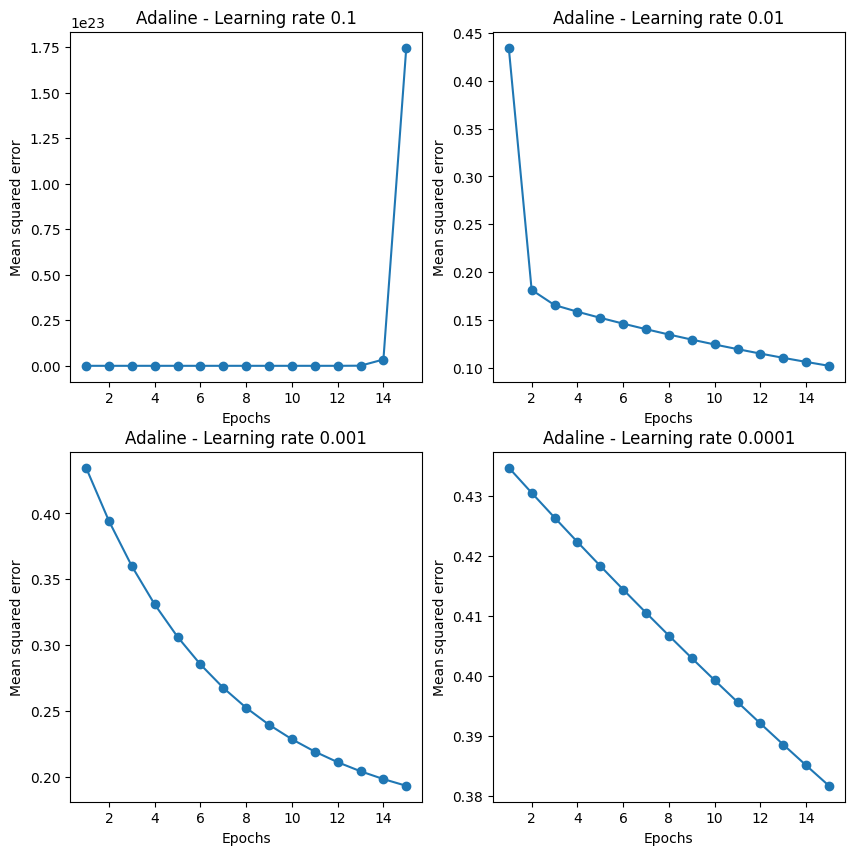

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X, y)
ax[0][0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Mean squared error')
ax[0][0].set_title('Adaline - Learning rate 0.1')
ada3 = AdalineGD(n_iter=15, eta=0.01).fit(X, y)
ax[0][1].plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker='o')
ax[0][1].set_xlabel('Epochs')
ax[0][1].set_ylabel('Mean squared error')
ax[0][1].set_title('Adaline - Learning rate 0.01')

ada4 = AdalineGD(n_iter=15, eta=0.001).fit(X, y)
ax[1][0].plot(range(1, len(ada4.losses_) + 1), ada4.losses_, marker='o')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Mean squared error')
ax[1][0].set_title('Adaline - Learning rate 0.001')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X, y)
ax[1][1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1][1].set_xlabel('Epochs')
ax[1][1].set_ylabel('Mean squared error')
ax[1][1].set_title('Adaline - Learning rate 0.0001')

plt.show()

Dla 1 najlepszy learning rate to 0.001

In [ ]:
# Standaryzacja cech (mean oraz std z NumPy):
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

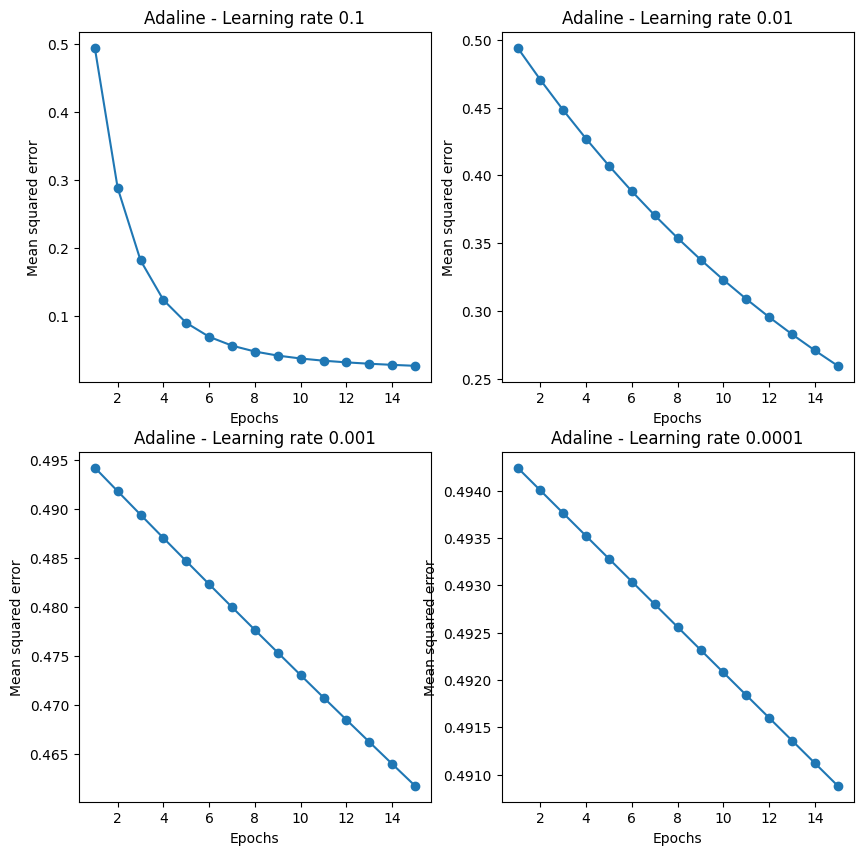

In [ ]:

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))


ada1 = AdalineGD(n_iter=15, eta=0.1).fit(X_std, y)
ax[0][0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Mean squared error')
ax[0][0].set_title('Adaline - Learning rate 0.1')
ada3 = AdalineGD(n_iter=15, eta=0.01).fit(X_std, y)
ax[0][1].plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker='o')
ax[0][1].set_xlabel('Epochs')
ax[0][1].set_ylabel('Mean squared error')
ax[0][1].set_title('Adaline - Learning rate 0.01')

ada4 = AdalineGD(n_iter=15, eta=0.001).fit(X_std, y)
ax[1][0].plot(range(1, len(ada4.losses_) + 1), ada4.losses_, marker='o')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Mean squared error')
ax[1][0].set_title('Adaline - Learning rate 0.001')

ada2 = AdalineGD(n_iter=15, eta=0.0001).fit(X_std, y)
ax[1][1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1][1].set_xlabel('Epochs')
ax[1][1].set_ylabel('Mean squared error')
ax[1][1].set_title('Adaline - Learning rate 0.0001')

plt.show()

learning rate dla 2 najlepsze 0.1

In [ ]:
class AdalineSGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ------------
    eta : float
      Learning rate (between 0.0 and 1.0)
    n_iter : int
      Passes over the training dataset.
    shuffle : bool (default: True)
      Shuffles training data every epoch if True to prevent cycles.
    random_state : int
      Random number generator seed for random weight
      initialization.


    Attributes
    -----------
    w_ : 1d-array
      Weights after fitting.
    b_ : Scalar
        Bias unit after fitting.
    losses_ : list
      Mean squared error loss function value averaged over all
      training examples in each epoch.


    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
          Training vectors, where n_examples is the number of examples and
          n_features is the number of features.
        y : array-like, shape = [n_examples]
          Target values.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_ += self.eta * 2.0 * xi * (error)
        self.b_ += self.eta * 2.0 * error
        loss = error**2
        return loss

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)

/tmp/ipykernel_174/2600498378.py:93: RuntimeWarning: overflow encountered in scalar power
  loss = error**2
/tmp/ipykernel_174/2600498378.py:91: RuntimeWarning: invalid value encountered in add
  self.w_ += self.eta * 2.0 * xi * (error)
/tmp/ipykernel_174/2600498378.py:92: RuntimeWarning: invalid value encountered in scalar add
  self.b_ += self.eta * 2.0 * error


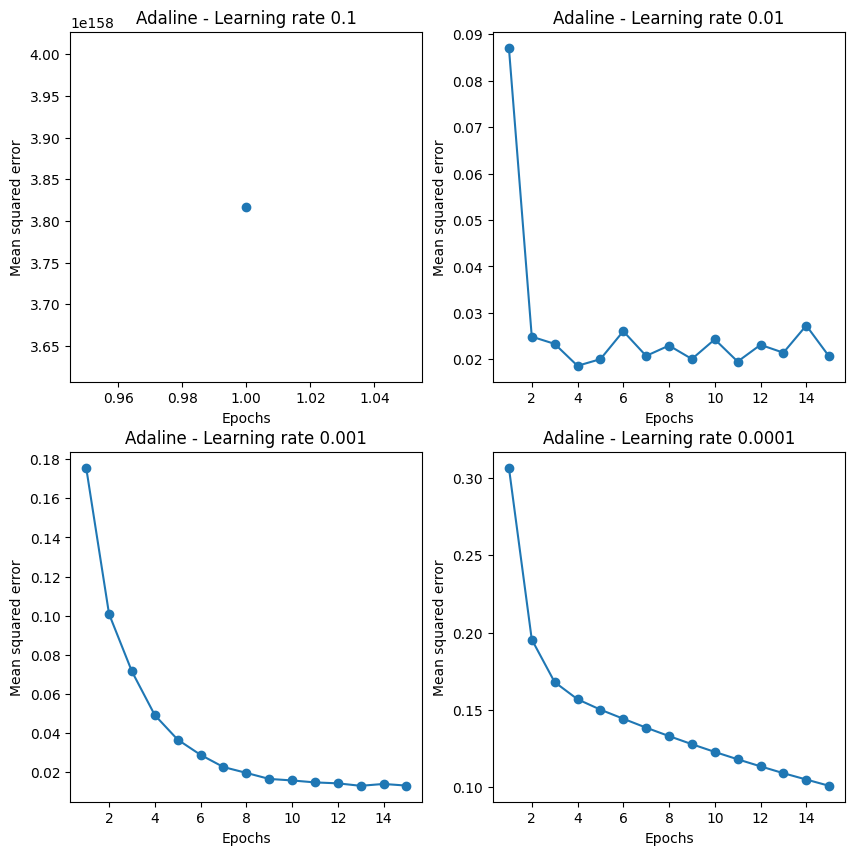

In [ ]:
from numpy.random.mtrand import rand


fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))


ada1 = AdalineSGD(n_iter=15, eta=0.1, random_state=1).fit(X, y)
ax[0][0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Mean squared error')
ax[0][0].set_title('Adaline - Learning rate 0.1')
ada3 = AdalineSGD(n_iter=15, eta=0.01, random_state=1).fit(X, y)
ax[0][1].plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker='o')
ax[0][1].set_xlabel('Epochs')
ax[0][1].set_ylabel('Mean squared error')
ax[0][1].set_title('Adaline - Learning rate 0.01')

ada4 = AdalineSGD(n_iter=15, eta=0.001,random_state=1).fit(X, y)
ax[1][0].plot(range(1, len(ada4.losses_) + 1), ada4.losses_, marker='o')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Mean squared error')
ax[1][0].set_title('Adaline - Learning rate 0.001')

ada2 = AdalineSGD(n_iter=15, eta=0.0001,random_state=1).fit(X, y)
ax[1][1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1][1].set_xlabel('Epochs')
ax[1][1].set_ylabel('Mean squared error')
ax[1][1].set_title('Adaline - Learning rate 0.0001')

plt.show()



DLa 3 najlepsze jest 0.001

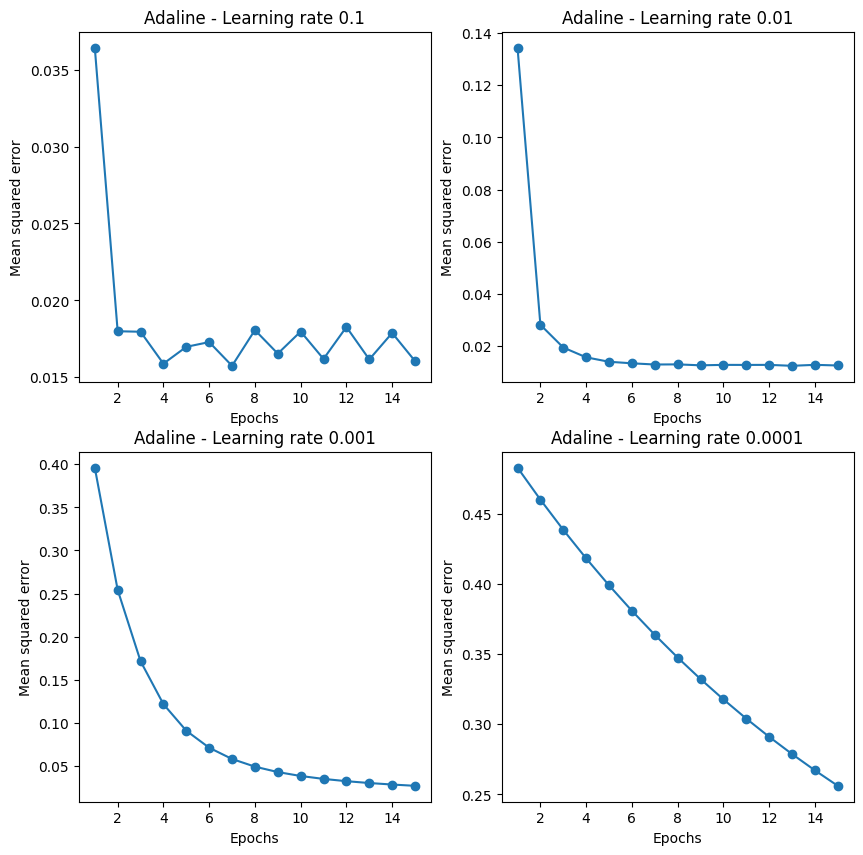

In [ ]:

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))


ada1 = AdalineSGD(n_iter=15, eta=0.1, random_state=1).fit(X_std, y)
ax[0][0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Mean squared error')
ax[0][0].set_title('Adaline - Learning rate 0.1')
ada3 = AdalineSGD(n_iter=15, eta=0.01, random_state=1).fit(X_std, y)
ax[0][1].plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker='o')
ax[0][1].set_xlabel('Epochs')
ax[0][1].set_ylabel('Mean squared error')
ax[0][1].set_title('Adaline - Learning rate 0.01')

ada4 = AdalineSGD(n_iter=15, eta=0.001,random_state=1).fit(X_std, y)
ax[1][0].plot(range(1, len(ada4.losses_) + 1), ada4.losses_, marker='o')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Mean squared error')
ax[1][0].set_title('Adaline - Learning rate 0.001')

ada2 = AdalineSGD(n_iter=15, eta=0.0001,random_state=1).fit(X_std, y)
ax[1][1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[1][1].set_xlabel('Epochs')
ax[1][1].set_ylabel('Mean squared error')
ax[1][1].set_title('Adaline - Learning rate 0.0001')

plt.show()

dla 4 najlepsze 0.1

Text(0.5, 1.0, 'AdalineSGD - Learning rate 0.01 ze standaryzacja')

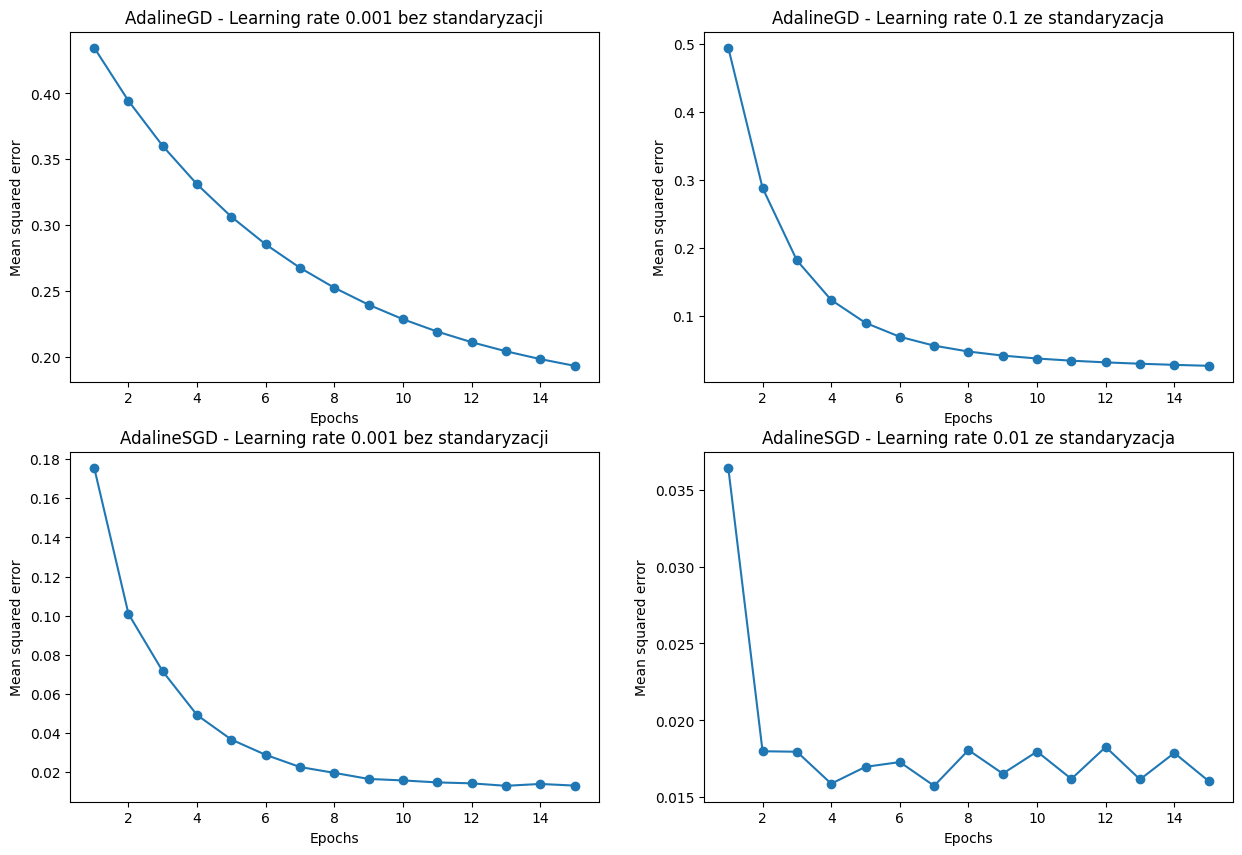

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
ada1 = AdalineGD(n_iter=15, eta=0.001).fit(X, y)
ax[0][0].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[0][0].set_xlabel('Epochs')
ax[0][0].set_ylabel('Mean squared error')
ax[0][0].set_title('AdalineGD - Learning rate 0.001 bez standaryzacji')

ada2 = AdalineGD(n_iter=15, eta=0.1).fit(X_std, y)
ax[0][1].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[0][1].set_xlabel('Epochs')
ax[0][1].set_ylabel('Mean squared error')
ax[0][1].set_title('AdalineGD - Learning rate 0.1 ze standaryzacja')

ada3 = AdalineSGD(n_iter=15, eta=0.001,random_state=1).fit(X, y)
ax[1][0].plot(range(1, len(ada3.losses_) + 1), ada3.losses_, marker='o')
ax[1][0].set_xlabel('Epochs')
ax[1][0].set_ylabel('Mean squared error')
ax[1][0].set_title('AdalineSGD - Learning rate 0.001 bez standaryzacji')

ada4 = AdalineSGD(n_iter=15, eta=0.1, random_state=1).fit(X_std, y)
ax[1][1].plot(range(1, len(ada4.losses_) + 1), ada4.losses_, marker='o')
ax[1][1].set_xlabel('Epochs')
ax[1][1].set_ylabel('Mean squared error')
ax[1][1].set_title('AdalineSGD - Learning rate 0.01 ze standaryzacja')



## Zadanie 2.2

Wybrać najlepsze z czterech rozważanych w ramach poprzedniego zadania podejść i zbudować model dla pełnego zbioru danych Iris (4 cechy, 3 klasy).

W celu poradzenia sobie z trzema klasami wykorzystać podejście OvA (one-versus-all)
(czasami nazywana także one-versus-rest, OvR).

Trenujemy po jednym klasyfikatorze dla każdej klasy -
wybrana klasa jest traktowana jako klasa pozytywna, a pozostałe klasy uznawane są za klasy negatywne.

Klasyfikacja polega na użyciu wszystkich klasyfikatorów ($k$ klasyfikatorów dla $k$ klas)
i wybraniu klasy, która według tych klasyfikatorów jest ,,najbardziej prawdopodobna" (ma najwyższy wynik).

Obliczyć błąd finalnego modelu na danych uczących (czyli w tym przypadku na całym zbiorze danych).

In [ ]:
import numpy as np

# Wydzielamy dwa gatunki (setosa oraz versicolor):
y = df.iloc[0:200, 4].values  # Wybiera wiersze od 0 do 99 i 5-tą kolumnę
y0=np.where(y=='Iris-setosa',0,1)
y1=np.where(y=='Iris-versicolor',0,1)
y2=np.where(y=='Iris-virginica',0,1)
                           # Metoda .values konwertuje tę kolumnę na tablicę NumPy

# Wydzielamy dwie cechy (sepal length oraz petal length):
X = df.iloc[0:200,[0,1,2,3]].values

print(X)
print(y0)
print(y1)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.1 1.5 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [ ]:
# Standaryzacja cech (mean oraz std z NumPy):
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

[118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118, 118]


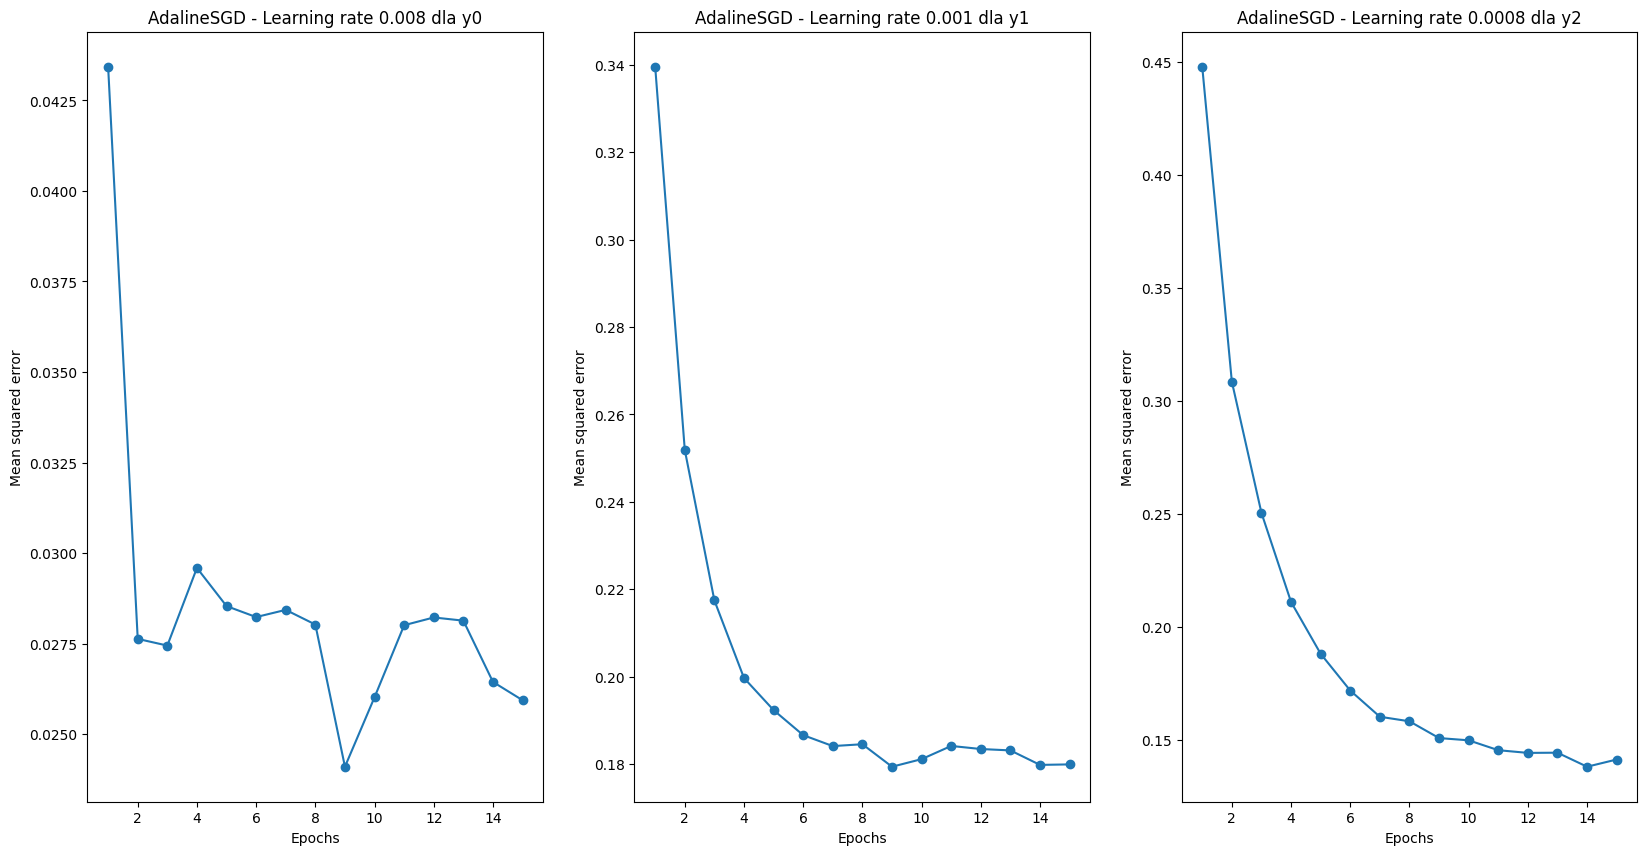

In [ ]:
import numpy as np

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20, 10))
ada0 = AdalineSGD(n_iter=15, eta=0.008, random_state=1).fit(X_std, y0)
ax[0].plot(range(1, len(ada0.losses_) + 1), ada0.losses_, marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Mean squared error')
ax[0].set_title('AdalineSGD - Learning rate 0.008 dla y0')

ada1 = AdalineSGD(n_iter=15, eta=0.001, random_state=1).fit(X_std, y1)
ax[1].plot(range(1, len(ada1.losses_) + 1), ada1.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('AdalineSGD - Learning rate 0.001 dla y1')

ada2 = AdalineSGD(n_iter=15, eta=0.0008, random_state=1).fit(X_std, y2)
ax[2].plot(range(1, len(ada2.losses_) + 1), ada2.losses_, marker='o')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Mean squared error')
ax[2].set_title('AdalineSGD - Learning rate 0.0008 dla y2')

test=[]

for i in range(len(X_std)):
  porzadek= [ada0.net_input(X_std), ada1.net_input(X_std), ada2.net_input(X_std)]
  a=np.argmax(porzadek)
  test.append(int(a))
print(test)


## Zadanie 2.3*

Zmodyfikować definicję klasy Adaline tak, aby do uczenia modelu wykorzystywała metodę gradientu prostego z minigrupami (rozmiar minigrup jako parametr metody):
w każdym przebiegu gradient obliczany jest na podstawie niewielkich grup losowo dobieranych danych.

Porównać działanie metody dla różnych rozmiarów minigrup (zaczynając od rozmiaru jeden, czyli od standardowej wersji SGD).

## Zadanie 2.4*

Zbadać zmianę jakości modelu (w sensie dopasowania do danych uczących) wraz ze wzrostem rozmiaru danych. Wykorzystać metodę `partial_fit` do douczania modelu przykład po przykładzie.

Wyniki przedstawić w formie wykresu (jakość od rozmiaru danych).

## Zadanie 2.5*

Powtórzyć poprzednie zadanie, tylko tym razem jakość modelu badać na odłożony zbiorze testowym rozmiaru $30\%$ całego zbioru danych.